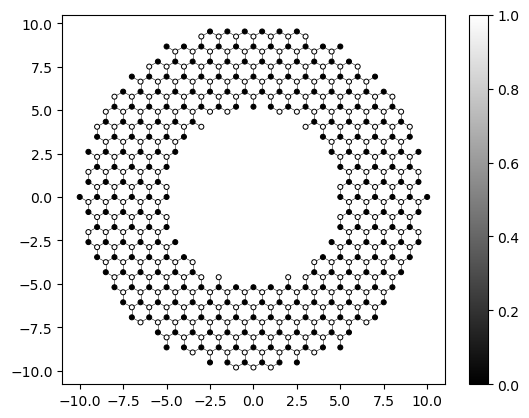

In [17]:
import kwant
import numpy as np
import matplotlib.pyplot as plt

# =====================
# 参数
# =====================
t = 1.0
r_inner = 5.0
r_outer = 10.0

# =====================
# 石墨烯晶格
# =====================
graphene = kwant.lattice.honeycomb()
a, b = graphene.sublattices

# =====================
# 甜甜圈形状
# =====================
def ring_shape(pos):
    x, y = pos
    r2 = x**2 + y**2
    return (r_inner**2 <= r2 <= r_outer**2)

# =====================
# onsite 位能
# =====================
def potential(site):
    return 0.0

# =====================
# 构建散射区
# =====================
syst = kwant.Builder()

# 🔴 关键修复：start 点必须在 ring 内
syst[graphene.shape(ring_shape, (6, 0))] = potential

# hopping
syst[graphene.neighbors()] = -t

# =====================
# 可视化
# =====================
def site_color(site):
    return 0 if site.family == a else 1

kwant.plot(
    syst,
    site_color=site_color,
    site_lw=0.1,
    hop_lw=0.05
);


In [18]:
def lead_shape(pos):
    x, y = pos
    return abs(y) <= 3
sym_left  = kwant.TranslationalSymmetry((-1, 0))
sym_right = kwant.TranslationalSymmetry((1, 0))

lead_left = kwant.Builder(sym_left)
lead_right = kwant.Builder(sym_right)

lead_left[graphene.shape(lead_shape, (0, 0))] = 0
lead_left[graphene.neighbors()] = -t

lead_right[graphene.shape(lead_shape, (0, 0))] = 0
lead_right[graphene.neighbors()] = -t

syst.attach_lead(lead_left)
syst.attach_lead(lead_right)



[Site(kwant.lattice.Monatomic([[1.0, 0.0], [0.5, 0.8660254037844386]], [0.0, 0.0], '0', None), array([11, -2])),
 Site(kwant.lattice.Monatomic([[1.0, 0.0], [0.5, 0.8660254037844386]], [0.0, 0.0], '0', None), array([11, -1])),
 Site(kwant.lattice.Monatomic([[1.0, 0.0], [0.5, 0.8660254037844386]], [0.0, 0.0], '0', None), array([11, 0])),
 Site(kwant.lattice.Monatomic([[1.0, 0.0], [0.5, 0.8660254037844386]], [0.0, 0.0], '0', None), array([11, 2])),
 Site(kwant.lattice.Monatomic([[1.0, 0.0], [0.5, 0.8660254037844386]], [0.0, 0.0], '0', None), array([11, 1])),
 Site(kwant.lattice.Monatomic([[1.0, 0.0], [0.5, 0.8660254037844386]], [0.0, 0.0], '0', None), array([11, 3])),
 Site(kwant.lattice.Monatomic([[1.0, 0.0], [0.5, 0.8660254037844386]], [0.0, 0.5773502691896258], '1', None), array([11, 0])),
 Site(kwant.lattice.Monatomic([[1.0, 0.0], [0.5, 0.8660254037844386]], [0.0, 0.5773502691896258], '1', None), array([11, -1])),
 Site(kwant.lattice.Monatomic([[1.0, 0.0], [0.5, 0.8660254037844386]], 

c:\Users\taoji\anaconda3\Lib\site-packages\kwant\lattice.py:120: KwantDeprecationWarning:

Not specfying norbs is deprecated. Always specify norbs when creating site families.



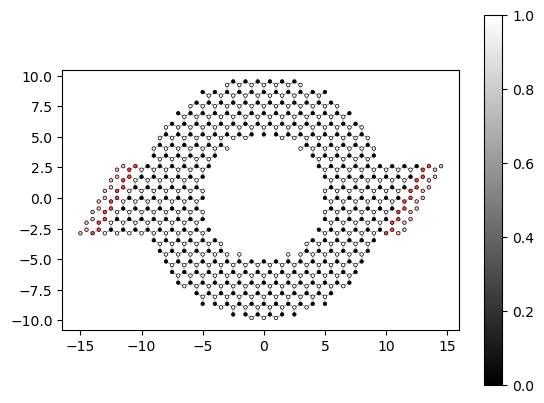

In [20]:
import kwant
import numpy as np
import matplotlib.pyplot as plt

t = 1.0
r_inner = 5.0
r_outer = 10.0

graphene = kwant.lattice.honeycomb()
a, b = graphene.sublattices

def ring_shape(pos):
    x, y = pos
    r2 = x**2 + y**2
    return r_inner**2 <= r2 <= r_outer**2

def lead_shape(pos):
    x, y = pos
    return abs(y) <= 3

syst = kwant.Builder()
syst[graphene.shape(ring_shape, (6, 0))] = 0
syst[graphene.neighbors()] = -t

# 左导线
sym_left = kwant.TranslationalSymmetry((-1, 0))
lead_left = kwant.Builder(sym_left)
lead_left[graphene.shape(lead_shape, (0, 0))] = 0
lead_left[graphene.neighbors()] = -t

# 右导线
sym_right = kwant.TranslationalSymmetry((1, 0))
lead_right = kwant.Builder(sym_right)
lead_right[graphene.shape(lead_shape, (0, 0))] = 0
lead_right[graphene.neighbors()] = -t

syst.attach_lead(lead_left)
syst.attach_lead(lead_right)

kwant.plot(
    syst,
    site_color=lambda site: 0 if site.family == a else 1,
    site_lw=0.1,
    hop_lw=0.05
);


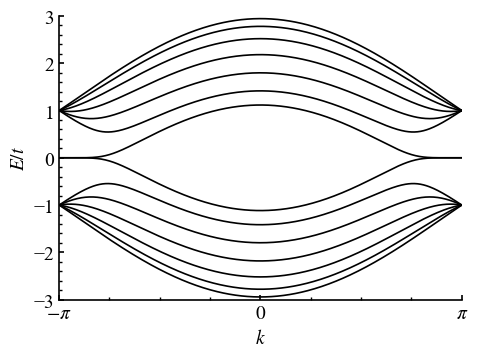

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import kwant
import os

# =====================
# 输出目录
# =====================
out_dir = r"D:\结果"
os.makedirs(out_dir, exist_ok=True)

# =====================
# finalize 系统
# =====================
fsyst = syst.finalized()
lead = fsyst.leads[0]

# =====================
# PRL 风格 matplotlib 设置
# =====================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "mathtext.fontset": "stix",
    "font.size": 14,
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.minor.width": 1.0,
    "ytick.minor.width": 1.0,
})

# =====================
# 画能带
# =====================
fig, ax = plt.subplots(figsize=(5.0, 3.8))

kwant.plotter.bands(
    lead,
    momenta=np.linspace(-np.pi, np.pi, 401),
    ax=ax,
    show=False
)

# —— 强制黑色 —— #
for line in ax.lines:
    line.set_color("k")
    line.set_linewidth(1.2)

# 坐标轴
ax.set_xlabel(r"$k$")
ax.set_ylabel(r"$E/t$")
ax.set_ylim(-3, 3)
ax.set_xlim(-np.pi, np.pi)

ax.set_xticks([-np.pi, 0, np.pi])
ax.set_xticklabels([r"$-\pi$", r"$0$", r"$\pi$"])

ax.minorticks_on()

# PRL 风格：去掉上、右边框
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()

# =====================
# 保存
# =====================
fig.savefig(os.path.join(out_dir, "graphene_lead_band.pdf"))
fig.savefig(os.path.join(out_dir, "graphene_lead_band.png"), dpi=600)

plt.show()


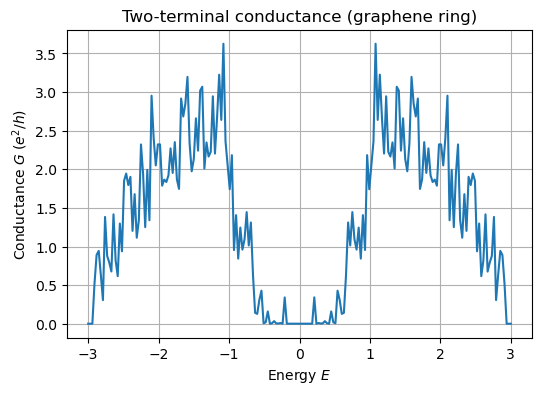

In [28]:
# =====================
# finalize 系统
# =====================
fsyst = syst.finalized()

energies = np.linspace(-3, 3, 201)
conductance = []

eta = 1e-6   # 极小能量偏移，避免奇异

for E in energies:
    try:
        smatrix = kwant.smatrix(fsyst, E + eta)
        G = smatrix.transmission(1, 0)
    except Exception:
        # 在 band edge / Dirac 点，直接置 0
        G = 0.0
    conductance.append(G)

conductance = np.array(conductance)

# =====================
# 作图
# =====================
plt.figure(figsize=(6, 4))
plt.plot(energies, conductance)
plt.xlabel("Energy $E$")
plt.ylabel(r"Conductance $G \; (e^2/h)$")
plt.title("Two-terminal conductance (graphene ring)")
plt.grid(True)
plt.show()


In [ ]:
import kwant
import numpy as np
import matplotlib.pyplot as plt

t = 1.0
L = 20   # 散射区长度
W = 3    # 半宽 |y| ≤ W

graphene = kwant.lattice.honeycomb()
a, b = graphene.sublattices

def ribbon_shape(pos):
    x, y = pos
    return (0 <= x <= L) and (abs(y) <= W)

syst = kwant.Builder()
syst[graphene.shape(ribbon_shape, (0, 0))] = 0
syst[graphene.neighbors()] = -t
def lead_shape(pos):
    x, y = pos
    return abs(y) <= W

# 左导线
sym_left = kwant.TranslationalSymmetry((-1, 0))
lead_left = kwant.Builder(sym_left)
lead_left[graphene.shape(lead_shape, (0, 0))] = 0
lead_left[graphene.neighbors()] = -t

# 右导线
sym_right = kwant.TranslationalSymmetry((1, 0))
lead_right = kwant.Builder(sym_right)
lead_right[graphene.shape(lead_shape, (0, 0))] = 0
lead_right[graphene.neighbors()] = -t

syst.attach_lead(lead_left)
syst.attach_lead(lead_right)



[Site(kwant.lattice.Monatomic([[1.0, 0.0], [0.5, 0.8660254037844386]], [0.0, 0.0], '0', None), array([22, -3])),
 Site(kwant.lattice.Monatomic([[1.0, 0.0], [0.5, 0.8660254037844386]], [0.0, 0.0], '0', None), array([22, 1])),
 Site(kwant.lattice.Monatomic([[1.0, 0.0], [0.5, 0.8660254037844386]], [0.0, 0.0], '0', None), array([22, 3])),
 Site(kwant.lattice.Monatomic([[1.0, 0.0], [0.5, 0.8660254037844386]], [0.0, 0.0], '0', None), array([22, 0])),
 Site(kwant.lattice.Monatomic([[1.0, 0.0], [0.5, 0.8660254037844386]], [0.0, 0.0], '0', None), array([22, -2])),
 Site(kwant.lattice.Monatomic([[1.0, 0.0], [0.5, 0.8660254037844386]], [0.0, 0.0], '0', None), array([22, -1])),
 Site(kwant.lattice.Monatomic([[1.0, 0.0], [0.5, 0.8660254037844386]], [0.0, 0.0], '0', None), array([22, 2])),
 Site(kwant.lattice.Monatomic([[1.0, 0.0], [0.5, 0.8660254037844386]], [0.0, 0.5773502691896258], '1', None), array([22, -3])),
 Site(kwant.lattice.Monatomic([[1.0, 0.0], [0.5, 0.8660254037844386]], [0.0, 0.577350

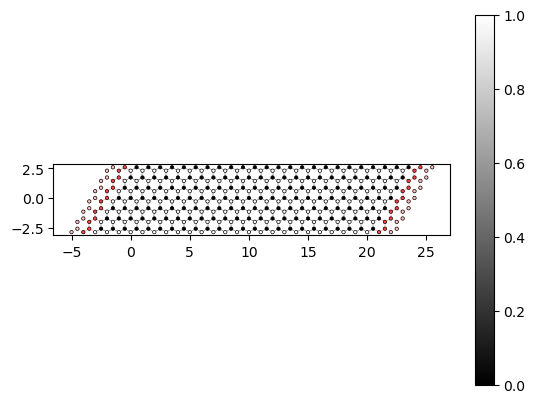

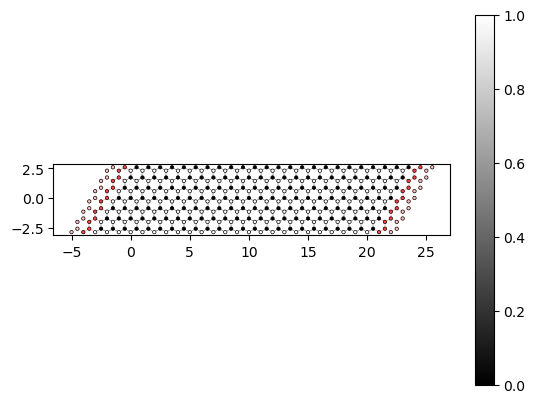

In [32]:
kwant.plot(
    syst,
    site_color=lambda site: 0 if site.family == a else 1,
    site_lw=0.1,
    hop_lw=0.05
)


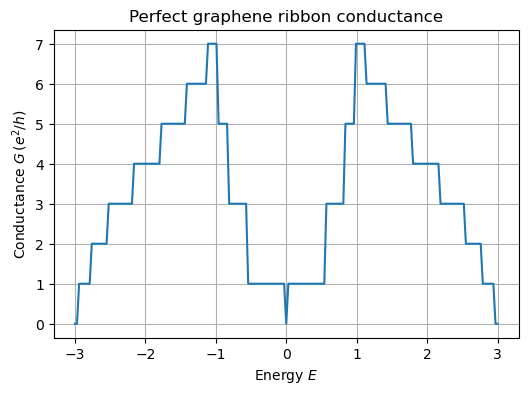

In [33]:
fsyst = syst.finalized()

energies = np.linspace(-3, 3, 201)
G = []

for E in energies:
    try:
        smat = kwant.smatrix(fsyst, E)
        G.append(smat.transmission(1, 0))
    except:
        G.append(0.0)

G = np.array(G)

plt.figure(figsize=(6,4))
plt.plot(energies, G)
plt.xlabel("Energy $E$")
plt.ylabel(r"Conductance $G\,(e^2/h)$")
plt.title("Perfect graphene ribbon conductance")
plt.grid(True)
plt.show()
